In [6]:
#enviroment setup
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import xgboost as xgb
import shap

import re

print("Environment Ready")

Environment Ready


In [7]:
#data loading
trades_raw = pd.read_csv('historical_data.csv')
fg_raw = pd.read_csv('fear_greed_index.csv')

print("Trades Shape:", trades_raw.shape)
print("Fear & Greed Shape:", fg_raw.shape)

display(trades_raw.head())
display(fg_raw.head())

Trades Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
#preprocessing
# Clean column names
def clean_cols(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r'[\s/]+', '_', regex=True)
        .str.replace(r'[^a-z0-9_]', '', regex=True)
    )
    return df

trades = clean_cols(trades_raw.copy())
fg = clean_cols(fg_raw.copy())

print(trades.columns)
print(fg.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [10]:
#timestamp column
# Detect timestamp column
time_col = [c for c in trades.columns if 'time' in c][0]

sample = trades[time_col].dropna().iloc[0]

if str(sample).isdigit():

    if float(sample) > 1e12:
        trades['timestamp'] = pd.to_datetime(trades[time_col], unit='ms', utc=True)
    else:
        trades['timestamp'] = pd.to_datetime(trades[time_col], unit='s', utc=True)

else:
    trades['timestamp'] = pd.to_datetime(trades[time_col], utc=True, infer_datetime_format=True, dayfirst=True)

trades['date'] = trades['timestamp'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

trades['year'] = trades['timestamp'].dt.year
trades['month'] = trades['timestamp'].dt.month
trades['hour'] = trades['timestamp'].dt.hour

print("Timestamp Processed")

Timestamp Processed


In [ ]:
# Clean Fear & Greed Index
date_col_fg = [c for c in fg.columns if 'date' in c][0]
cls_col_fg  = [c for c in fg.columns if 'class' in c or 'sentiment' in c][0]

fg.rename(columns={date_col_fg: 'date', cls_col_fg: 'sentiment'}, inplace=True)
fg['date'] = pd.to_datetime(fg['date'])
fg['sentiment'] = fg['sentiment'].str.strip().str.title()

SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
fg['sentiment_code'] = fg['sentiment'].map(
    {s: i for i, s in enumerate(SENTIMENT_ORDER)}
)

print("Sentiment distribution:")
print(fg['sentiment'].value_counts())


In [12]:
# Fear & Greed preprocessing

date_col_fg = [c for c in fg.columns if 'date' in c][0]
cls_col_fg = [c for c in fg.columns if 'class' in c or 'sentiment' in c][0]

fg.rename(columns={
    date_col_fg: 'date',
    cls_col_fg: 'sentiment'
}, inplace=True)

fg['date'] = pd.to_datetime(fg['date'])

fg['sentiment'] = fg['sentiment'].str.strip().str.title()

sentiment_map = {
    'Extreme Fear': 0,
    'Fear': 1,
    'Neutral': 2,
    'Greed': 3,
    'Extreme Greed': 4
}

fg['sentiment_code'] = fg['sentiment'].map(sentiment_map)

display(fg.head())

,timestamp,value,sentiment,date,sentiment_code
0,1517463000,30,Fear,2018-02-01,1
1,1517549400,15,Extreme Fear,2018-02-02,0
2,1517635800,40,Fear,2018-02-03,1
3,1517722200,24,Extreme Fear,2018-02-04,0
4,1517808600,11,Extreme Fear,2018-02-05,0


In [13]:
#column mapping
# Column Mapping

col_map = {}

for col in trades.columns:

    if re.search(r'pnl|profit|loss', col):
        col_map['pnl'] = col

    elif re.search(r'price|exec', col):
        col_map['price'] = col

    elif re.search(r'size|qty|amount', col):
        col_map['size'] = col

    elif re.search(r'side|dir', col):
        col_map['side'] = col

    elif re.search(r'leverage|lev', col):
        col_map['leverage'] = col

    elif re.search(r'symbol|coin|asset', col):
        col_map['symbol'] = col

    elif re.search(r'account|trader|user', col):
        col_map['account'] = col

print(col_map)

{'account': 'account', 'symbol': 'coin', 'price': 'execution_price', 'size': 'size_usd', 'side': 'direction', 'pnl': 'closed_pnl'}


In [14]:
#renaming columns
reverse_map = {v:k for k,v in col_map.items()}

trades.rename(columns=reverse_map, inplace=True)

# Convert numeric columns
for c in ['pnl', 'price', 'size', 'leverage']:

    if c in trades.columns:
        trades[c] = pd.to_numeric(trades[c], errors='coerce')

display(trades.head())

,account,symbol,price,size_tokens,size,side,timestamp_ist,start_position,side,pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,year,month,hour
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02 22:50:00+00:00,2024-12-02,2024,12,22
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02 22:50:00+00:00,2024-12-02,2024,12,22
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02 22:50:00+00:00,2024-12-02,2024,12,22
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02 22:50:00+00:00,2024-12-02,2024,12,22
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02 22:50:00+00:00,2024-12-02,2024,12,22


In [15]:
#merging datasets
df = trades.merge(
    fg[['date', 'sentiment', 'sentiment_code']],
    on='date',
    how='left'
)

df['sentiment'] = df['sentiment'].fillna(method='ffill')
df['sentiment_code'] = df['sentiment_code'].fillna(method='ffill')

df.dropna(subset=['pnl'], inplace=True)

df['is_profit'] = (df['pnl'] > 0).astype(int)

print(df.shape)

display(df.head())

(211224, 23)


,account,symbol,price,size_tokens,size,side,timestamp_ist,start_position,side,pnl,...,fee,trade_id,timestamp,date,year,month,hour,sentiment,sentiment_code,is_profit
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,0.345404,8.950000e+14,2024-12-02 22:50:00+00:00,2024-12-02,2024,12,22,Extreme Greed,4.0,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,0.005600,4.430000e+14,2024-12-02 22:50:00+00:00,2024-12-02,2024,12,22,Extreme Greed,4.0,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,0.050431,6.600000e+14,2024-12-02 22:50:00+00:00,2024-12-02,2024,12,22,Extreme Greed,4.0,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,0.050043,1.080000e+15,2024-12-02 22:50:00+00:00,2024-12-02,2024,12,22,Extreme Greed,4.0,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,0.003055,1.050000e+15,2024-12-02 22:50:00+00:00,2024-12-02,2024,12,22,Extreme Greed,4.0,0


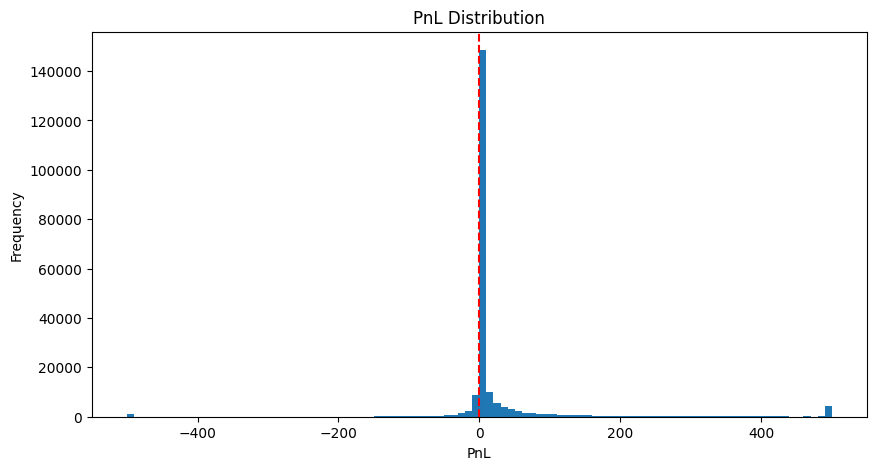

In [16]:
#eda
plt.figure(figsize=(10,5))

plt.hist(df['pnl'].clip(-500,500), bins=100)

plt.axvline(0, color='red', linestyle='--')

plt.title("PnL Distribution")
plt.xlabel("PnL")
plt.ylabel("Frequency")

plt.show()

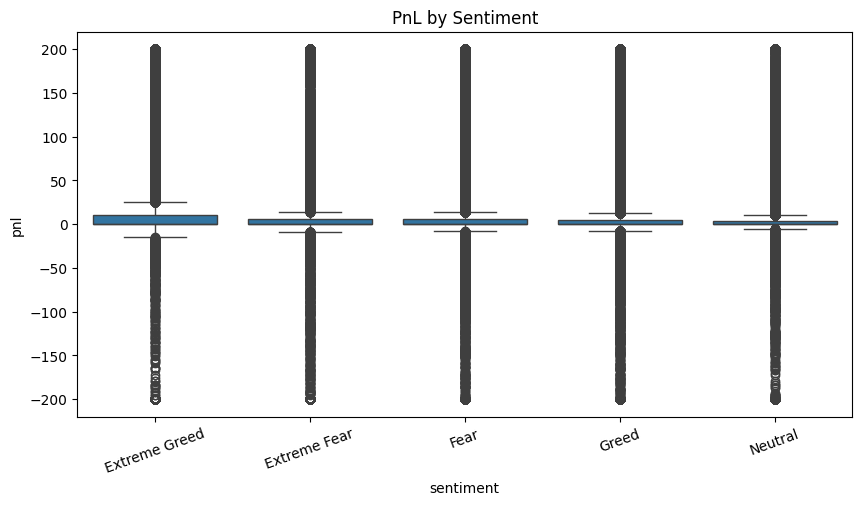

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='sentiment',
    y=df['pnl'].clip(-200,200)
)

plt.title("PnL by Sentiment")

plt.xticks(rotation=20)

plt.show()

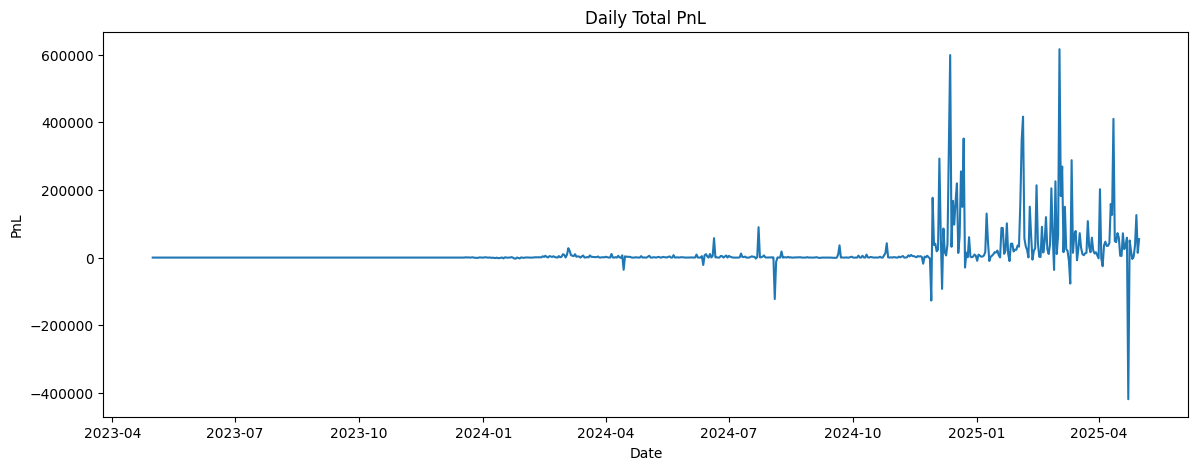

In [18]:
daily_trades = df.groupby('date').agg({
    'pnl':'sum'
}).reset_index()

plt.figure(figsize=(14,5))

plt.plot(daily_trades['date'], daily_trades['pnl'])

plt.title("Daily Total PnL")

plt.xlabel("Date")
plt.ylabel("PnL")

plt.show()

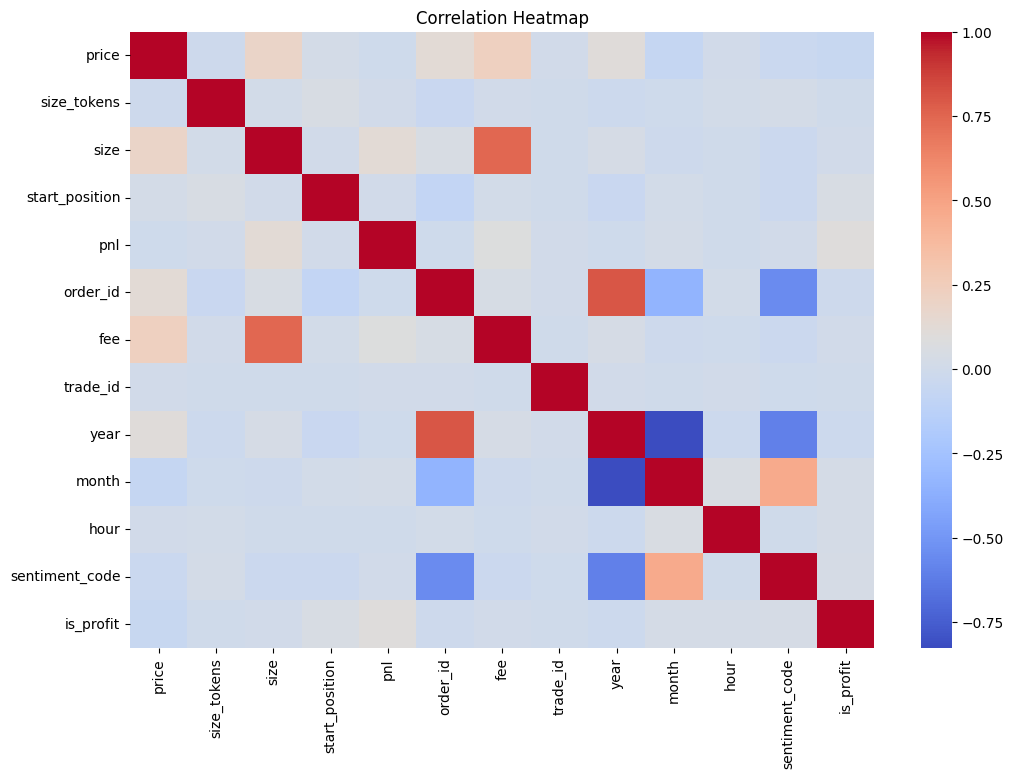

In [19]:
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [20]:
#feautures
df['abs_pnl'] = df['pnl'].abs()

if 'size' in df.columns:
    df['pnl_per_unit'] = df['pnl'] / df['size'].replace(0, np.nan)

if 'price' in df.columns and 'size' in df.columns:
    df['notional'] = df['price'] * df['size']

if 'leverage' in df.columns:
    df['effective_lev'] = df['leverage'].clip(1, 200)

display(df.head())

,account,symbol,price,size_tokens,size,side,timestamp_ist,start_position,side,pnl,...,date,year,month,hour,sentiment,sentiment_code,is_profit,abs_pnl,pnl_per_unit,notional
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,2024-12-02,2024,12,22,Extreme Greed,4.0,0,0.0,0.0,62795.433104
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,2024-12-02,2024,12,22,Extreme Greed,4.0,0,0.0,0.0,1018.886400
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,2024-12-02,2024,12,22,Extreme Greed,4.0,0,0.0,0.0,9188.355865
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,2024-12-02,2024,12,22,Extreme Greed,4.0,0,0.0,0.0,9121.930296
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,2024-12-02,2024,12,22,Extreme Greed,4.0,0,0.0,0.0,557.260650


In [21]:
#trader Level Aggregation
trader_stats = df.groupby('account').agg({
    'pnl':['sum','mean','std','count'],
    'is_profit':'mean'
})

trader_stats.columns = [
    'total_pnl',
    'avg_pnl',
    'pnl_std',
    'trade_count',
    'win_rate'
]

trader_stats = trader_stats.reset_index()

display(trader_stats.head())

,account,total_pnl,avg_pnl,pnl_std,trade_count,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,4692.452329,3818,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,134.073473,7280,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,542.182659,3809,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,113.269353,13311,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,255.829091,3239,0.519914


In [22]:
#clustering
cluster_features = [
    'avg_pnl',
    'pnl_std',
    'trade_count',
    'win_rate'
]

ts_clean = trader_stats.dropna()

X = ts_clean[cluster_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(32, 4)


In [23]:
#kMeans Clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

ts_clean['cluster'] = kmeans.fit_predict(X_scaled)

display(ts_clean.head())

,account,total_pnl,avg_pnl,pnl_std,trade_count,win_rate,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,4692.452329,3818,0.359612,1
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,134.073473,7280,0.442720,2
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,542.182659,3809,0.301917,2
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,113.269353,13311,0.438585,0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,255.829091,3239,0.519914,2


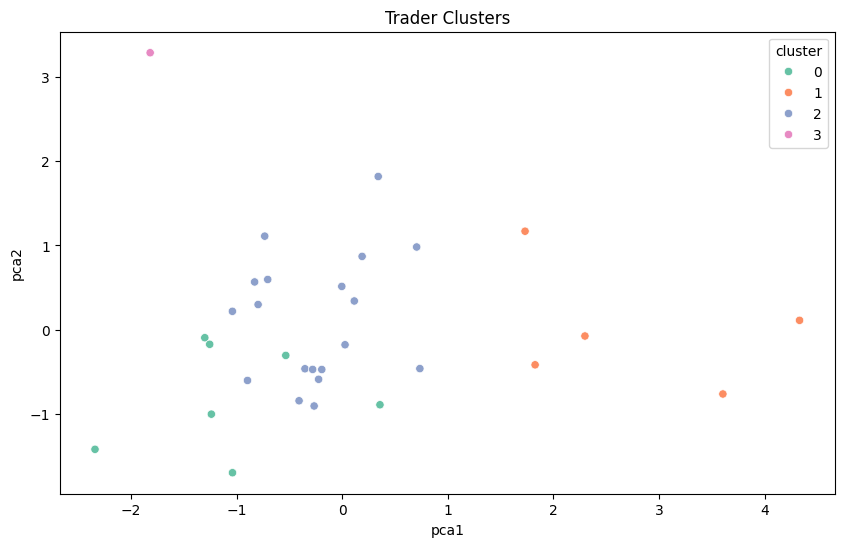

In [24]:
#PCA Visualization
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

ts_clean['pca1'] = X_pca[:,0]
ts_clean['pca2'] = X_pca[:,1]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=ts_clean,
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='Set2'
)

plt.title("Trader Clusters")

plt.show()

In [25]:
# Machine Learning
features = [
    'sentiment_code'
]

if 'effective_lev' in df.columns:
    features.append('effective_lev')

X = df[features].fillna(0)

y = df['is_profit']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.59      1.00      0.74     24802
           1       0.00      0.00      0.00     17443

    accuracy                           0.59     42245
   macro avg       0.29      0.50      0.37     42245
weighted avg       0.34      0.59      0.43     42245

